In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
(df.isnull().sum()/len(df))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [10]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [12]:
df.drop('Cabin', axis=1, inplace=True)

In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

In [17]:
df['Embarked'] = le.fit_transform(df['Embarked'])

In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


In [19]:
df = df.drop(['PassengerId','Name','Ticket'], axis=1)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [21]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [22]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


In [23]:
scaler = MinMaxScaler()

X_normalized = scaler.fit_transform(X)

X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

X_normalized.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,1.0,0.271174,0.125,0.0,0.014151,1.0
1,0.0,0.0,0.472229,0.125,0.0,0.139136,0.0
2,1.0,0.0,0.321438,0.000,0.0,0.015469,1.0
3,0.0,0.0,0.434531,0.125,0.0,0.103644,1.0
4,1.0,1.0,0.434531,0.000,0.0,0.015713,1.0


In [24]:
std = StandardScaler()

X_standardized = std.fit_transform(X)

X_standardized = pd.DataFrame(X_standardized, columns=X.columns)

X_standardized.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.827377,0.737695,-0.565736,0.432793,-0.473674,-0.502445,0.585954
1,-1.566107,-1.355574,0.663861,0.432793,-0.473674,0.786845,-1.942303
2,0.827377,-1.355574,-0.258337,-0.474545,-0.473674,-0.488854,0.585954
3,-1.566107,-1.355574,0.433312,0.432793,-0.473674,0.420730,0.585954
4,0.827377,0.737695,0.433312,-0.474545,-0.473674,-0.486337,0.585954


In [25]:
print("Original Data")
print(X.head())

print("\nNormalized Data")
print(X_normalized.head())

print("\nStandardized Data")
print(X_standardized.head())

Original Data
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2

Normalized Data
   Pclass  Sex       Age  SibSp  Parch      Fare  Embarked
0     1.0  1.0  0.271174  0.125    0.0  0.014151       1.0
1     0.0  0.0  0.472229  0.125    0.0  0.139136       0.0
2     1.0  0.0  0.321438  0.000    0.0  0.015469       1.0
3     0.0  0.0  0.434531  0.125    0.0  0.103644       1.0
4     1.0  1.0  0.434531  0.000    0.0  0.015713       1.0

Standardized Data
     Pclass       Sex       Age     SibSp     Parch      Fare  Embarked
0  0.827377  0.737695 -0.565736  0.432793 -0.473674 -0.502445  0.585954
1 -1.566107 -1.355574  0.663861  0.432793 -0.473674  0.786845 -1.942303
2  0.827377 -1.355574 -0.258337 -0.474545 -0.473674 -0.4

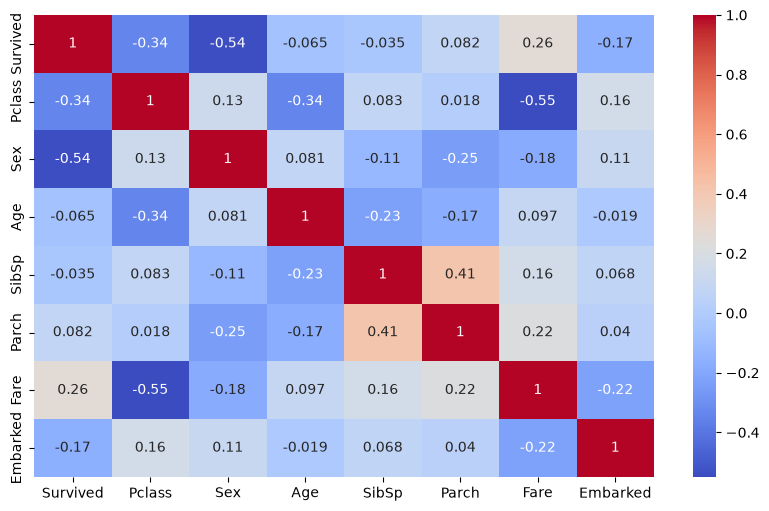

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

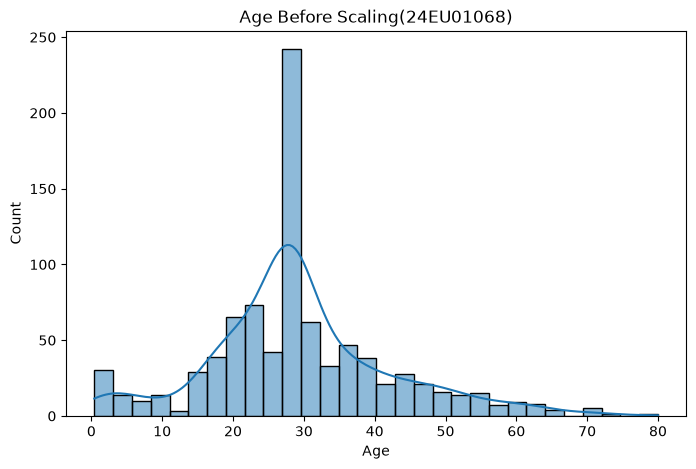

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], kde=True)

plt.title("Age Before Scaling(24EU01068)")

plt.show()

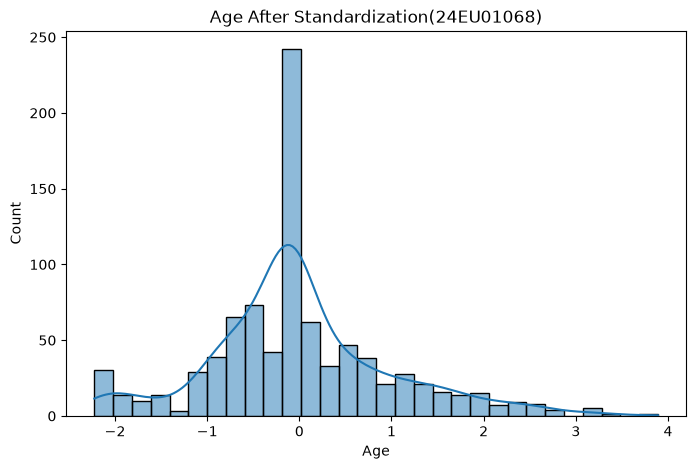

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(X_standardized['Age'], kde=True)

plt.title("Age After Standardization(24EU01068)")

plt.show()

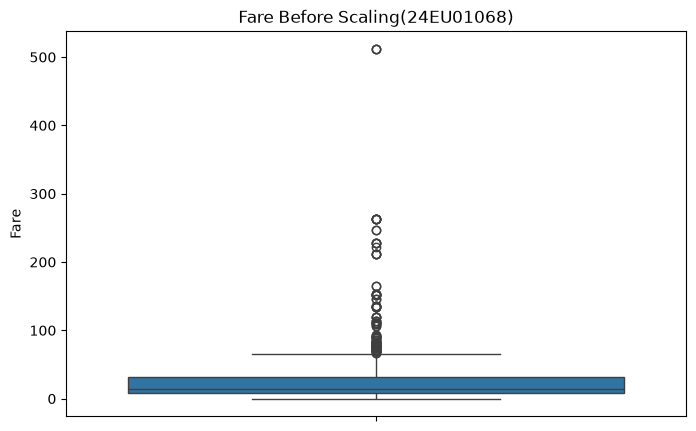

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['Fare'])

plt.title("Fare Before Scaling(24EU01068)")

plt.show()

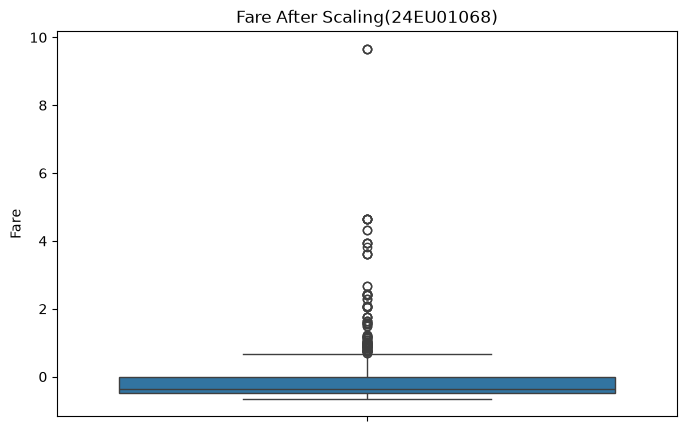

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(y=X_standardized['Fare'])

plt.title("Fare After Scaling(24EU01068)")

plt.show()

In [31]:
processed_data = X_standardized.copy()

processed_data['Survived'] = y.values

processed_data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,0.827377,0.737695,-0.565736,0.432793,-0.473674,-0.502445,0.585954,0
1,-1.566107,-1.355574,0.663861,0.432793,-0.473674,0.786845,-1.942303,1
2,0.827377,-1.355574,-0.258337,-0.474545,-0.473674,-0.488854,0.585954,1
3,-1.566107,-1.355574,0.433312,0.432793,-0.473674,0.420730,0.585954,1
4,0.827377,0.737695,0.433312,-0.474545,-0.473674,-0.486337,0.585954,0


In [32]:
processed_data.to_csv("Titanic_Preprocessed.csv", index=False)

In [33]:
print("1. Missing values handled successfully.")
print("2. Duplicate records removed.")
print("3. Categorical variables encoded.")
print("4. Unnecessary columns removed.")
print("5. Data normalized and standardized.")
print("6. Dataset is ready for machine learning models.")

1. Missing values handled successfully.
2. Duplicate records removed.
3. Categorical variables encoded.
4. Unnecessary columns removed.
5. Data normalized and standardized.
6. Dataset is ready for machine learning models.
